<!--
CSI-6-ARI Week 8 Tutorial
Artificial Neural Networks
-->

<style>
  :root{
    --bg:#0b1320;
    --fg:#eef3fb;
    --muted:#b9c6dc;
    --card:#ffffff;
    --line:#e6eaf2;
    --soft:#f6f8fb;
    --info:#eef6ff;
    --warn:#fff7e6;
    --task:#fff0f3;
    --ok:#eefaf0;
    --infoLine:#cfe5ff;
    --warnLine:#ffe1a6;
    --taskLine:#ffd1dc;
    --okLine:#bfe8c7;
  }

  /* Consistent notebook typography */
  .markdown, .markdown p, .markdown li, .markdown div { font-size: 16px; line-height: 1.65; }
  h1 { font-size: 36px; margin: 0 0 12px 0; }
  h2 { font-size: 24px; margin: 22px 0 10px 0; }
  h3 { font-size: 19px; margin: 16px 0 8px 0; }

  .hero{
    padding:20px 22px;
    border-radius:18px;
    background:var(--bg);
    color:var(--fg);
    border:1px solid rgba(255,255,255,0.12);
  }
  .hero .subtitle{margin-top:10px;font-size:18px;font-weight:650;color:var(--muted);}
  .hero .meta{margin-top:10px;font-size:14px;color:var(--muted);}

  .grid{display:grid;grid-template-columns:1fr 1fr;gap:12px;margin-top:14px;}
  .card{
    padding:14px 16px;
    border-radius:16px;
    background:var(--card);
    border:1px solid var(--line);
    box-shadow:0 1px 0 rgba(20,30,50,0.04);
  }
  .card h3{margin:0 0 10px 0;font-size:18px;}

  .box{padding:14px 16px;border-radius:16px;border:1px solid var(--line);background:var(--soft);margin:12px 0;}
  .box.info{background:var(--info);border-color:var(--infoLine);}
  .box.warn{background:var(--warn);border-color:var(--warnLine);}
  .box.task{background:var(--task);border-color:var(--taskLine);}
  .box.ok{background:var(--ok);border-color:var(--okLine);}

  .boxtitle{font-weight:850;font-size:18px;margin:0 0 8px 0;display:flex;gap:10px;align-items:center;}

  .badge{
    width:28px;height:28px;
    border-radius:9px;
    display:inline-flex;align-items:center;justify-content:center;
    font-weight:900;font-size:16px;
    border:1px solid rgba(0,0,0,0.08);
  }
  .b-info{background:#dbeafe;color:#1d4ed8;}
  .b-warn{background:#ffedd5;color:#c2410c;}
  .b-task{background:#ffe4e6;color:#be123c;}
  .b-ok{background:#dcfce7;color:#166534;}

  code{background:#f1f5f9;border-radius:6px;padding:1px 6px;}
  details{border:1px dashed #cbd5e1;border-radius:14px;padding:10px 12px;background:#fbfdff;}
  summary{cursor:pointer;font-weight:850;font-size:16px;}
</style>

<div class="hero">
  <h1><b>CSI-6-ARI, Week 8 Tutorial</b></h1>
  <div class="subtitle">Artificial Neural Networks</div>
</div>

<div class="grid">
  <div class="card">
    <h3>🎯 Learning outcomes</h3>
    <ul>
      <li>Explain what an artificial neural network is, and how it differs from a simple linear model.</li>
      <li>Prepare tabular data for ANN training, including train/test split and feature scaling.</li>
      <li>Build a feed-forward ANN in Keras, selecting layers, activations, and output configuration.</li>
      <li>Train and evaluate an ANN using accuracy and a confusion matrix, then apply basic regularisation and early stopping.</li>
    </ul>
  </div>
  <div class="card">
    <h3>🧭 How to use this notebook</h3>
    <ul>
      <li>Run cells top-to-bottom. Later sections assume earlier variables exist.</li>
      <li>Exercises use an empty code cell. Complete it before opening the answer.</li>
      <li>Answers are in collapsible boxes with explanation.</li>
    </ul>
  </div>
</div>


# **Artificial Neural Networks**

The neural network in AI is based on the concept of biological neural networks. In general, our brain is connected with more than 80 billion neurons. The human neural system has three stages: receptors (receive the stimuli and pass the information to the outside environment), neural networks (make a decision for output after processing the input), and effectors (translate information of neural networks into a response). The concept of deep learning is also based on a similar approach. In this tutorial, we will see the whole concept of neural networking of AI using the Artificial Neural Network (ANN) with Keras.


In [ ]:
import numpy as np
import pandas as pd

# Set random seed to ensure reproducible runs
RSEED = 50

# Part I - Deep Learning based Classification Example #


##Dataset

Step 1 of any data analysis in Google Colab is to upload the data set. Here, the Pima Indian diabetes dataset is uploaded first. This dataset is available on Kaggle ([link](https://www.kaggle.com/uciml/pima-indians-diabetes-database)). The diabetes dataset contains several columns that may play an important role in the risk of diabetes. These columns are:

* Number of pregnancies
* Glucose
* Blood pressure
* Skin thickness
* Insulin
* BMI
* Diabetes pedigree function
* Age
* Outcome (diabetic or non-diabetic)

In [ ]:
df = pd.read_csv('diabetes.csv')

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##Importing The Libraries

Libraries in python play a pivotal role in data analysis. Here, NumPy, pandas, and TensorFlow have been imported. It is important to remember that you may face different types of challenges in different datasets. Hence, you may have to use a different set of libraries or many other libraries.

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

##  Data Preprocessing ##

It is difficult to imagine any data analysis with the preprocessing of the data set. Again, every dataset comes with a different challenge. Hence, excellent knowledge of python is essential. The most common challenge in data preprocessing is the exclusion of inconsequential columns and conversion of categorical data, such as gender into 0 and 1. The current diabetes dataset only requires separation of independent (X) and dependent (y) variables.

In [ ]:
X=df.iloc[:,0:-1].values
y=df.iloc[:, -1].values

Splitting of the dataset into training and test sets is necessary. The training set is used to apply the machine learning model. Hence, a large portion of data is randomly selected as a training set from the whole dataset. Here, 80% of data is selected as a training set (test_size = 0.2). The random state is required to achieve a similar splitting of dataset each time we run ANN. Otherwise, there will be a slight change in results. The test set is used to evaluate the model. Scikit library is required to split the dataset.    

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=0.2, random_state=0)

## Feature Scaling ##

Feature scaling is performed to normalize or standardized all independent variables. Some variables, such as age and salary are totally on different scales, hence may have a different effect on Euclidean distance (there are many other ways to calculate distance such as Manhattan distance). Therefore, all independent variables should be on the same scale. If we perform feature scaling before splitting the dataset, the mean value of the whole data set will influence the result. Hence, feature scaling should be done after scaling the data set.  Feature scaling is an essential step as there is going to be a lot of computation in ANN and you wouldn’t want any independent variable to dominate on any other variable.    

In [ ]:
from sklearn.preprocessing import StandardScaler
sc= StandardScaler()
X_train =sc.fit_transform(X_train)
X_test =sc.fit_transform(X_test)

##  Building the ANN model ##

The next step of ANN is to build a model. Keras library is now integrated into the new version of TensorFlow (2.0). Sequential class is used to initialize the ANN as a sequence of layers as follows.   

In [ ]:
ANN=tf.keras.models.Sequential()

The next few steps required the formation of sequence layers for ANN. In this step, you will be adding the input layer and the hidden layer. To add these layers, you should use a dense class. This dense class is used in whatever phase of the neural network we are, as it is also evident by my few next steps. Here, the add method is used to add anything such as a hidden layer from the sequential class using the 'ANN' variable. The layer module is used to add classes, which means layers you want to add in our ANN. The number of units here suggests a number of hidden neurons or hidden layers. Our input neurons or layers are all of our independent variables.

### Adding the input layer and the first hidden layer ###

In [ ]:
ANN.add(tf.keras.layers.Dense(units=4, activation='relu'))

There is no specific rule to choose a number of units. It is experimentally based. You have to use different hyperparameters. Here, you can see four, based on several trials. There are many functions that may require based on different approaches. In this blog, you will see just two of the unit and activation functions. For a fully connected hidden layer, the rectifier activation function (relu) is used. This rectifier function is mostly suggested to connect hidden layers. Nonetheless, it is good to have a basic understanding of all activation functions, as things may change based on different datasets.      

### Adding the Second Hidden Layer ###

The next step is adding the second hidden layer.

In [ ]:
ANN.add(tf.keras.layers.Dense(units=4, activation='relu'))

### Adding the output layer ###

Adding the output layer in ANN is slightly different than adding a hidden layer. It is important to know the dimension of the output layer. In this dataset, you will be predicting binary variables (0 or 1), hence dimension is one. It means you just need one neuron to predict the final output. Remember, this is an example of a classification approach. Another important change in this layer is the activation function. Here, you can see the use of the sigmoid function, because it not only gives a better prediction than rectifier function but also provide the probabilities. Hence, you will get the prediction that if someone is having diabetes or not, including their probabilities.

In [ ]:
ANN.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

##Training the ANN
The next step is to train the created model on our training set. Training of ANN requires two steps.

### Compiling the ANN
The first step is to compile the ANN with an optimizer, lost function, and metrics. Here, in metrics, you are using accuracy function, as you are using classification (binary dependent variables). The first argument is the optimizer. The optimizer is used for the optimization algorithm we want to use to find the optimal set of weights in the neural networks. Here, you will be using ‘adam’ optimization which is an extension of stochastic gradient descent. If you check the mathematical detail of stochastic gradient descent, you can find that it is based on the lost function that you need to optimize to find the optimal weights. The lost function is not the sum of squares square errors like for linear regression but it's going to be a logarithmic function that is called a logarithmic loss. When the weights are updated after each observation or after each batch of many observations the algorithm uses this accuracy criterion to improve the model’s performance. The name adam is derived from adaptive moment estimation. Next is computing the cross-entropy loss between true labels and predicted labels. Use this cross-entropy loss when there are only two label classes (assumed to be 0 and 1).

In [ ]:
ANN.compile(optimizer='adam', loss= 'binary_crossentropy', metrics =['accuracy'])

###Training the ANN on the Training set
The next step is fitting the ANN of the training dataset. Two arguments in this example are used to fit the training model, epochs, and batch size. The sample size for the diabetes dataset is 768. Batch size 50 suggests the number of samples processed before our ANN model is updated. One epoch is when an entire dataset is passed forward and backward through the neural network only ONCE.

In [ ]:
ANN.fit(X_train, y_train, batch_size=50,epochs=200 )

Epoch 1/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4067 - loss: 0.8222
Epoch 2/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4144 - loss: 0.7958
Epoch 3/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4158 - loss: 0.7756
Epoch 4/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4138 - loss: 0.7630
Epoch 5/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4750 - loss: 0.7387
Epoch 6/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.4871 - loss: 0.7234
Epoch 7/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5039 - loss: 0.7204
Epoch 8/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5465 - loss: 0.6995
Epoch 9/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5236 - loss: 0.6985
Epoch 10/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5694 - loss: 0.6891
Epoch 11/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5766 - loss: 0.6798
Epoch 12/200
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - a

Let's draw model's convergence.

In [ ]:
losses = pd.DataFrame(ANN.history.history)

<Axes: >

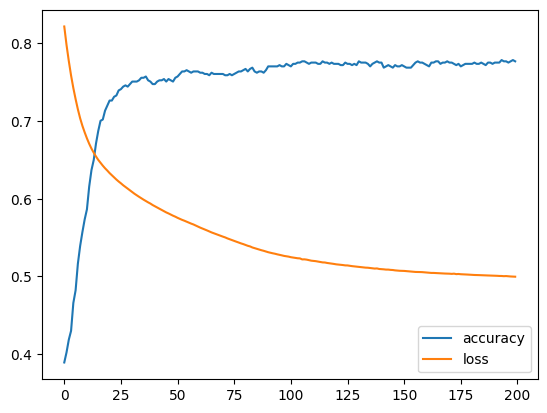

In [ ]:
losses.plot()

## Making the Predictions and Evaluating the Model ##
Now the ANN model is ready and also performed on the training dataset. But, how would we know if it is good? We will check our model using the test data set, however, only using independent variables. Results from the predicted test dataset will then be compared with the original results.

### Predicting the Test set results

As the dataset being used has a binary outcome, a classification approach of supervised machine learning is used here. The first step is to predict the outcome of the test dataset using the independent variable, here X_test, using the ‘ann’ model trained on the training dataset. As you used sigmoid activation function for output, hence the results are in probability. Next, you will have to convert those probabilities into true ( > 0.05) or false (<0.05) and then change those true and false into 0 and 1.

In [ ]:
y_pred = ANN.predict(X_test)
y_pred = (y_pred > 0.5)
y_pred = y_pred.astype(int)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


### Making the Confusion Matrix ###

The confusion matrix is used to compare the predicted results of the test dataset with the original results of the test dataset. Scikit library is required to create a confusion matrix, here 2 x 2 table.   

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[95 12]
 [19 28]]


0.7987012987012987

The accuracy of the model prediction is 77.92%. Actually it is a good prediction. It is impossible to get 100% accuracy. If you get 100% accuracy for your model, then think again. That model is too good to be true. Hence, the rechecking of those models is highly recommended.

<b>=============================  EXERCISE  =============================</b>


<div class="box task">
  <div class="boxtitle"><span class="badge b-task">📝</span> Quick task, tune your ANN</div>
  <p>Try to tune hyperparameters of the ANN model you just created in order to achieve a better accuracy rate.</p>
  <ul>
    <li>Try changing: number of layers, units, activation functions, batch size, epochs, optimiser, learning rate.</li>
    <li>Use a validation split and compare training vs validation performance.</li>
  </ul>
</div>

In [ ]:
# TODO: Hyperparameter tuning
# 1) Start from the existing ANN model above
# 2) Modify 2-3 hyperparameters
# 3) Retrain and report the new accuracy

# Write your code here


<details>
<summary><b>✅ Hints (click to expand)</b></summary>

- Start by changing <code>epochs</code> (e.g., 50 → 150) and adding <code>validation_split=0.2</code>.
- Then try increasing hidden units (e.g., 6 → 16 or 32), or adding an extra hidden layer.
- Consider <code>EarlyStopping</code> to avoid overfitting.

</details>

<b>===================================================================</b>


# Part 2 - Exercise ANN Application #

Download the 'Churn_Modelling.csv' dataset from the VLE, and import it to your notebook.

In [ ]:
dataset = pd.read_csv('Churn_Modelling.csv')

Split independent (X) and dependent (y) variables.

In [ ]:
X = dataset.iloc[:, 3:-1].values
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [ ]:
y=dataset["Exited"]
print(y)

0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64


Encode the categorical data using LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

Label Encoding the "Gender" column

In [ ]:
X[:, 2] = le.fit_transform(X[:, 2])
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


Use One Hot Encoding for the "Geography" column

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [ ]:
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))
print(X)

[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


Split the dataset into the Training set and Test set

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

Perform feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [ ]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Build the ANN model

In [ ]:
ann = tf.keras.models.Sequential()

Add the input layer and the first hidden layer (You can use RELU activation function)

In [ ]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

Add the second hidden layer (You can use RELU activation function)

In [ ]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

Add the output layer (You can use sigmoid activation function)

In [ ]:
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

Compile the ANN model (you can use the following hyperparameters: optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [ ]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

Train the ANN model on the Training set (take batch_size = 32, epochs = 100)

In [ ]:
ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6584 - loss: 0.6269
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7976 - loss: 0.4846
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7988 - loss: 0.4588
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8100 - loss: 0.4400
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8210 - loss: 0.4240
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8178 - loss: 0.4294
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8266 - loss: 0.4172
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8265 - loss: 0.4140
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8225 - loss: 0.4182
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8277 - loss: 0.4024
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8265 - loss: 0.4075
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

Draw loss vs accuracy rate:

<Axes: >

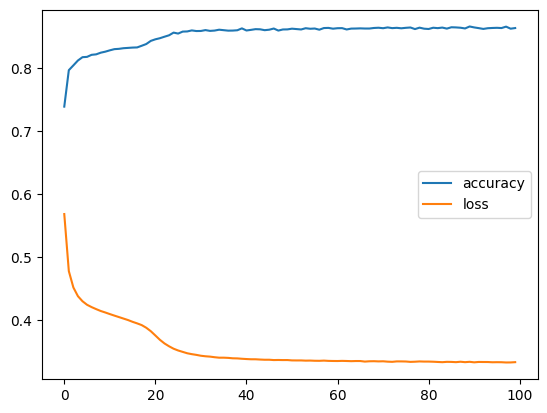

In [ ]:
losses = pd.DataFrame(ann.history.history)
losses.plot()

Generate confusion matrix

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score

In [ ]:
y_pred = ann.predict(X_test)
y_pred = (y_pred > 0.5)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[1527   68]
 [ 208  197]]


Evaluate the accuracy of the model

In [ ]:
accuracy_score(y_test, y_pred)

0.862

**Homework**

Use your ANN model to predict if the customer with the following informations will leave the bank:

Geography: France

Credit Score: 600

Gender: Male

Age: 40 years old

Tenure: 3 years

Balance: $ 60000

Number of Products: 2

Does this customer have a credit card ? Yes

Is this customer an Active Member: Yes

Estimated Salary: $ 50000

So, should we say goodbye to that customer ?

In [ ]:
print(ann.predict(sc.transform([[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])) > 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
[[False]]


## 3) ✅ Exercises


<div class="box task">
  <div class="boxtitle"><span class="badge b-task">🧪</span> Exercise 1, improve the diabetes ANN with early stopping</div>
  <p>Using the <b>Pima Indians diabetes</b> workflow in Part I, improve generalisation by introducing <b>EarlyStopping</b> and comparing performance before vs after.</p>
  <ul>
    <li>Add <code>validation_split</code> and <code>EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)</code>.</li>
    <li>Train for a larger max epoch count (e.g., 200) and let early stopping pick the best epoch.</li>
    <li>Report accuracy and briefly interpret whether the model is overfitting.</li>
  </ul>
</div>

In [ ]:
# TODO (Exercise 1)
# Add validation split and early stopping to the ANN training above.

from tensorflow.keras.callbacks import EarlyStopping

# early_stop = EarlyStopping(...)
# history = ann.fit(..., callbacks=[early_stop], ...)

# Evaluate and print accuracy


<details>
<summary><b>✅ Suggested approach (click to expand)</b></summary>

- Use something like:
  - <code>EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)</code>
  - <code>ann.fit(X_train, y_train, epochs=200, batch_size=32, validation_split=0.2, callbacks=[early_stop])</code>
- After training, evaluate on <code>X_test</code>, then compare with your earlier baseline accuracy.
- If training accuracy increases while validation/test accuracy stalls or drops, that is a sign of overfitting.

</details>

<div class="box task">
  <div class="boxtitle"><span class="badge b-task">📝</span> Exercise 2, churn prediction, clean preprocessing and evaluation</div>
  <p>For the <b>Churn_Modelling.csv</b> dataset (Part 2), tidy the workflow so the preprocessing and model training are easy to re-run and evaluate consistently.</p>
  <ul>
    <li>Check class balance (<code>Exited</code>), then report <b>accuracy</b> and <b>confusion matrix</b>.</li>
    <li>Try one improvement: class weights, dropout, or batch normalisation.</li>
    <li>State what changed and whether it improved performance.</li>
  </ul>
</div>

In [ ]:
# TODO (Exercise 2)
# 1) Load Churn_Modelling.csv
# 2) Preprocess (encoding + scaling)
# 3) Train an ANN and evaluate (accuracy + confusion matrix)
# 4) Add one improvement (dropout OR class weights OR batch norm)

# Write your code here


<details>
<summary><b>✅ Suggested approach (click to expand)</b></summary>

- Start by reproducing the baseline in Part 2, then change <b>one</b> thing at a time.
- If classes are imbalanced, try <code>class_weight</code> in <code>fit</code> (compute weights with <code>sklearn.utils.class_weight</code>).
- For regularisation, try Dropout between dense layers, e.g. <code>Dropout(0.2)</code>.
- Always evaluate on the held-out test set (<code>X_test</code>, <code>y_test</code>) using <code>confusion_matrix</code> and a short written interpretation.

</details>

<b>✅ Week 8 Tutorial Complete</b>

<p>
  This concludes <b>Week 8, Artificial Neural Networks</b>.
  You should now be able to explain what an <b>artificial neural network</b> is (and how it differs from a simple linear model), prepare tabular data for ANN training using a proper <b>train/test split</b> and <b>feature scaling</b>, and build a basic <b>feed-forward network in Keras</b> by selecting suitable layers, activations, and an appropriate output configuration.
  You should also be able to train and evaluate an ANN using <b>accuracy</b> and a <b>confusion matrix</b>, and apply simple techniques to improve generalisation, including <b>regularisation</b> and <b>early stopping</b>.
</p>
